Khởi tạo

In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle 

Tải dữ liệu

In [265]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
print('Train Shape: ',train.shape)
print('Test Shape: ',test.shape)
print(train.info())
print(test.info())

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual   

Kiểm tra giá trị NULL và bắt đầu huấn luyện dữ liệu

In [266]:
print(train.isnull().sum)

<bound method DataFrame.sum of          Id  MSSubClass  MSZoning  LotFrontage  LotArea  Street  Alley  \
0     False       False     False        False    False   False   True   
1     False       False     False        False    False   False   True   
2     False       False     False        False    False   False   True   
3     False       False     False        False    False   False   True   
4     False       False     False        False    False   False   True   
...     ...         ...       ...          ...      ...     ...    ...   
1455  False       False     False        False    False   False   True   
1456  False       False     False        False    False   False   True   
1457  False       False     False        False    False   False   True   
1458  False       False     False        False    False   False   True   
1459  False       False     False        False    False   False   True   

      LotShape  LandContour  Utilities  ...  PoolArea  PoolQC  Fence  \
0       

<Axes: >

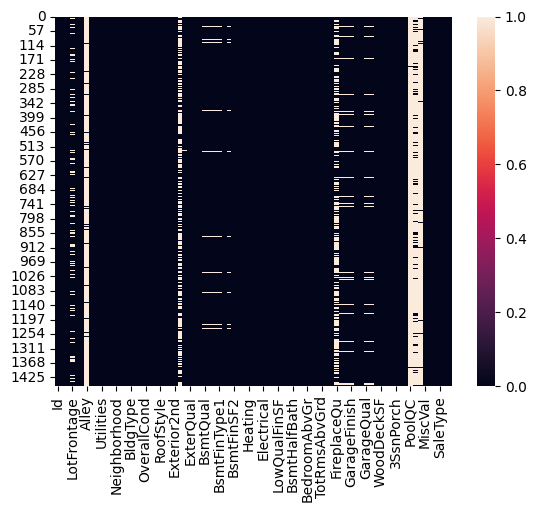

In [267]:
sns.heatmap(train.isnull())

Kiểm tra dữ liệu

In [268]:
print(test.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

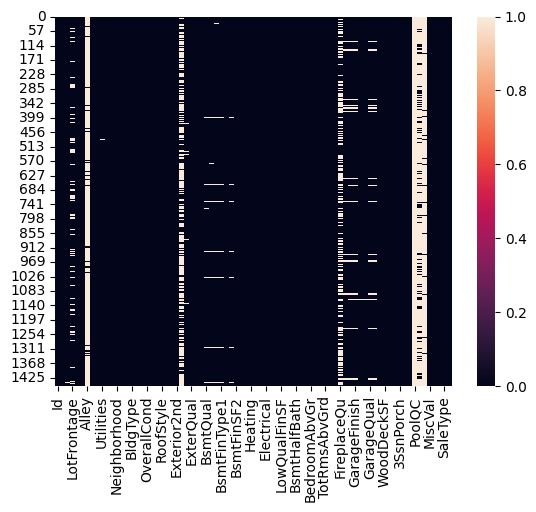

In [269]:
sns.heatmap(test.isnull())

Xử lý thông tin bị thiếu

Cho Train Data

In [270]:
cat_col_train=['FireplaceQu','GarageType','GarageFinish','MasVnrType',
'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
'FireplaceQu','GarageQual','GarageCond']
ncat_col_train=['LotFrontage','GarageYrBlt','MasVnrArea']
for i in cat_col_train:
    train[i]=train[i].fillna(train[i].mode()[0])
for j in ncat_col_train:
    train[j]=train[j].fillna(train[j].mean())

Cho Test Data

In [271]:
cat_col_test = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']

ncat_col_test=['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
'BsmtHalfBath', 'GarageCars', 'GarageArea']

for i in cat_col_test:
   test[i] =test[i].fillna(test[i].mode()[0])

for j in ncat_col_test:
   test[j] =test[j].fillna(test[j].mean())

Loại bỏ các cột

Train Shape: (1460, 76)
Test Shape:  (1459, 75)


(2919, 76)

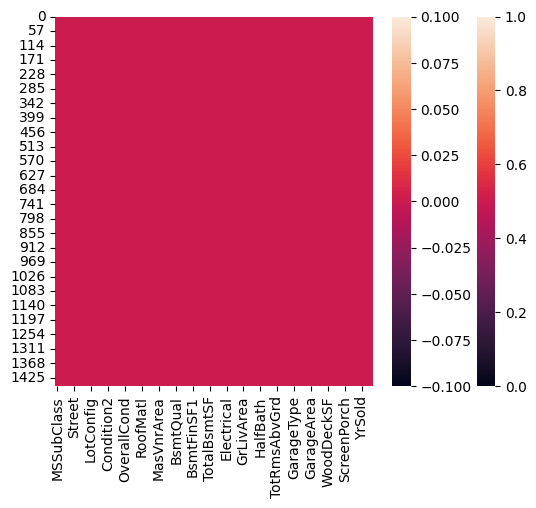

In [272]:
to_drop =['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
for k in to_drop:
    train.drop([k], axis= 1, inplace= True)
    test.drop([k], axis= 1, inplace= True)
sns.heatmap(train.isnull())
sns.heatmap(test.isnull())
print("Train Shape:",train.shape)
print("Test Shape: ", test.shape)
final_df =pd.concat([train, test], axis=0)
final_df.shape

In [273]:
all_cat_col = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'] 
def cat_onehot_encoding(multicol): 
    df_final = final_df
    i = 0

    for fields in multicol:
        print(fields)

        df1 = pd.get_dummies(final_df[fields], drop_first=True)
        final_df.drop([fields], axis=1, inplace=True)

        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis=1)

        i = i + 1

    df_final = pd.concat([final_df, df_final], axis=1)
    return df_final
final_df = cat_onehot_encoding(all_cat_col)
final_df.shape
final_df = final_df.loc[:, ~final_df.columns.duplicated()]
final_df.shape

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


(2919, 176)

Chia dữ liệu để train và test

In [274]:
# Tách dữ liệu về lại Train và Test 
df_train = final_df.iloc[:1460, :] 
df_test = final_df.iloc[1460:, :] 
df_test.drop(['SalePrice'], axis=1, inplace=True)  
print("Train Shape: ", df_train.shape) 
print("Test Shape: ", df_test.shape)

Train Shape:  (1460, 176)
Test Shape:  (1459, 175)


Huấn luyện dữ liệu

In [275]:
x_train = df_train.drop(['SalePrice'], axis=1) 
y_train = df_train['SalePrice']

Mô hình XGboost

In [276]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ==============================
# 1. Lấy model tốt nhất
# ==============================
xgb_model = random_cv.best_estimator_

print("Best parameters:")
print(random_cv.best_params_)


# ==============================
# 2. Kiểm tra shape
# ==============================
print("ndf_test shape:", df_test.shape)
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


# ==============================
# 3. Đánh giá bằng cross-validation (out-of-fold)
# ==============================
y_oof = cross_val_predict(xgb_model, x_train, y_train, cv=5, n_jobs=-1)

mae = mean_absolute_error(y_train, y_oof)
mse = mean_squared_error(y_train, y_oof)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_oof)

print("nModel Evaluation (5-fold CV):")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)


# ==============================
# 4. Dự đoán tập test (để nộp Kaggle, không tính metric)
# ==============================
y_test_pred = xgb_model.predict(df_test)

Best parameters:
{'n_estimators': 300, 'min_child_weight': 4, 'max_depth': 3, 'learning_rate': 0.15, 'booster': 'gbtree', 'base_score': 0.75}
ndf_test shape: (1459, 175)
x_train shape: (1460, 175)
y_train shape: (1460,)
nModel Evaluation (5-fold CV):
MAE : 16153.622509096747
MSE : 737768504.1561263
RMSE: 27161.894340346113
R2  : 0.8830199404701838


Lưu mô hình

In [277]:
f = "xgb_model.pkl" 
pickle.dump(xgb_model, open(f, 'wb'))

Dự đoán dữ liệu test

In [278]:
pred_xgb = xgb_model.predict(df_test)

Xuất file nộp bài

In [279]:
sub_df = pd.read_csv('sample_submission.csv') 
sub_df['SalePrice'] = pred_xgb 
sub_df.to_csv('sample_sub_xgb.csv', index=False)

Cây quyết định

In [280]:
from sklearn.tree import DecisionTreeClassifier

# Khởi tạo và huấn luyện mô hình
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

Dự đoán

In [281]:
pred_dt = dt_model.predict(df_test)

Xuất file

In [282]:
sub_df = pd.read_csv('sample_submission.csv')

sub_df['SalePrice'] = pred_dt

sub_df.to_csv('sample_sub_dt.csv', index=False)

Mô hình Mạng thần kinh nhân tạo

In [283]:
import numpy as np
import pandas as pd
import keras
from keras import layers, ops
from sklearn.preprocessing import StandardScaler

# ==============================
# 1. Ép kiểu và căn chỉnh cột
# ==============================
X = x_train.astype("float32")
X_test = df_test[X.columns].astype("float32")   # cùng cột, cùng thứ tự với train

print("NaN train:", X.isna().sum().sum(), "| NaN test:", X_test.isna().sum().sum())
# Nếu có NaN thì fillna trước, nếu không loss sẽ thành nan

# ==============================
# 2. Chuẩn hóa đặc trưng (fit trên train, áp dụng cho test)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 3. Target: log1p (BỎ dòng này nếu y_train đã ở thang log)
# ==============================
y = np.log1p(y_train.astype("float32").values).reshape(-1, 1)

# ==============================
# 4. Mô hình
# ==============================
@keras.saving.register_keras_serializable()
def root_mean_squared_error(y_true, y_pred):
    return ops.sqrt(ops.mean(ops.square(y_pred - y_true)))

nn_model = keras.Sequential([
    keras.Input(shape=(X_scaled.shape[1],)),
    layers.Dense(50, kernel_initializer="he_uniform", activation="relu"),
    layers.Dense(25, kernel_initializer="he_uniform", activation="relu"),
    layers.Dense(50, kernel_initializer="he_uniform", activation="relu"),
    layers.Dense(1, kernel_initializer="he_uniform"),
])

nn_model.compile(loss=root_mean_squared_error, optimizer="Adamax")

history = nn_model.fit(
    X_scaled,
    y,
    validation_split=0.25,
    batch_size=32,
    epochs=500,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=40, restore_best_weights=True
        )
    ],
)

print("Best val RMSE (log):", min(history.history["val_loss"]))

# ==============================
# 5. Lưu mô hình
# ==============================
nn_model.save("nn_model.keras")

# ==============================
# 6. Dự đoán và xuất submission
# ==============================
pred_log = nn_model.predict(X_test_scaled).flatten()
pred_nn = np.expm1(pred_log)          # đổi ngược từ log về giá thật

sub_df = pd.read_csv("sample_submission.csv")
assert len(sub_df) == len(pred_nn), "Số dòng submission không khớp số dòng test"
sub_df["SalePrice"] = pred_nn
sub_df.to_csv("sample_sub_nn.csv", index=False)

NaN train: 0 | NaN test: 0
Epoch 1/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 10.0142 - val_loss: 7.5010
Epoch 2/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.4138 - val_loss: 3.5808
Epoch 3/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.5515 - val_loss: 2.7365
Epoch 4/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.8826 - val_loss: 2.2809
Epoch 5/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.4494 - val_loss: 2.0186
Epoch 6/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1266 - val_loss: 1.8820
Epoch 7/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.8756 - val_loss: 1.7828
Epoch 8/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6938 - val_loss: 1.7043
Epoch 9/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5139 - val_loss: 1.6520
Epoch 10/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3739 - val_loss: 1.6098
Epoch 11/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2621 - val_loss: 1.5724
Epoch 12/500
35/35 ━━━━━━━━━━━━━